In [140]:
from pricer import Analytical
import matplotlib.pyplot as plt
import numpy as np

# Vanilla Call Option

## Price

In [141]:
S, K, r, T, sigma, q, option_type = 100, 100, 0.05, 1, 0.2, 0, 'call'

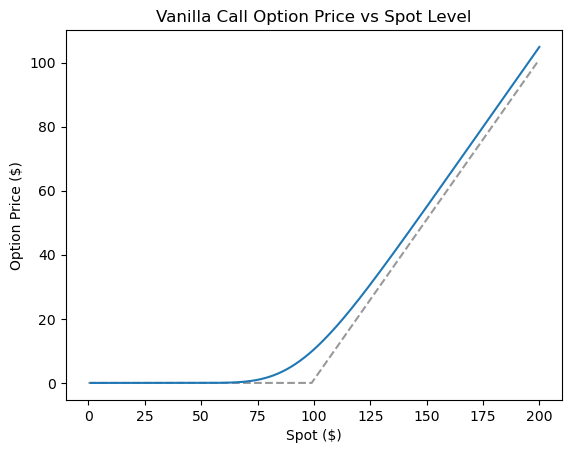

In [142]:
spot_range = np.linspace(start=S*0.01, stop=S*2, num=200)
val = []

for i in spot_range:
    analytical = Analytical(i, K, r, T, sigma, q, option_type)
    val.append(analytical.price())

intrinsic_val = [max(i-K, 0) for i in spot_range]

plt.plot(intrinsic_val, color='grey', alpha=0.8, linestyle='dashed')
plt.plot(spot_range, val)
plt.xlabel('Spot ($)')
plt.ylabel('Option Price ($)')
plt.title('Vanilla Call Option Price vs Spot Level')
plt.show()

## Greeks

### vs Spot

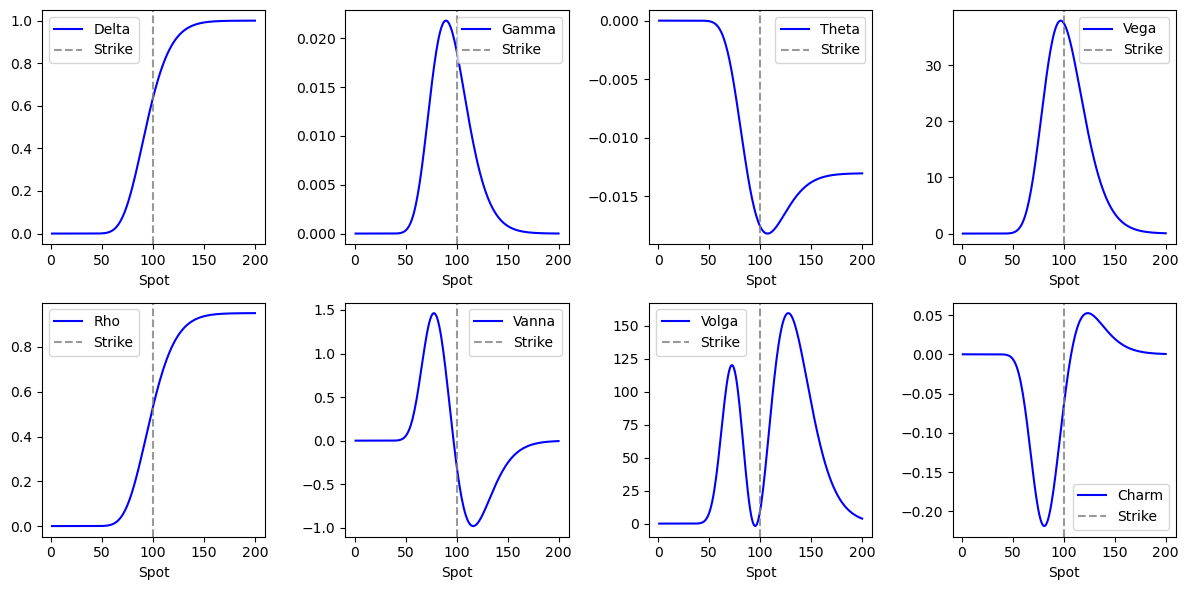

In [143]:
spot_range = np.linspace(start=S*0.01, stop=S*2, num=200)
metrics = ['Delta', 'Gamma', 'Theta', 'Vega', 'Rho', 'Vanna', 'Volga', 'Charm']

val = {j: [] for j in metrics}

for j in metrics:
    for i in spot_range:
        analytical = Analytical(i, K, r, T, sigma, q, option_type)
        val[j].append(analytical.greeks()[j])

plt.figure(figsize=(12,6))

for idx, i in enumerate(val):
    plt.subplot(2, 4, idx+1)
    plt.plot(spot_range, val[i], label=i, color='blue')
    plt.axvline(x=K, color='grey', linestyle='--', label='Strike', alpha=0.8)
    plt.xlabel('Spot')
    plt.legend()

plt.tight_layout()
plt.show()

### vs Spot and Time

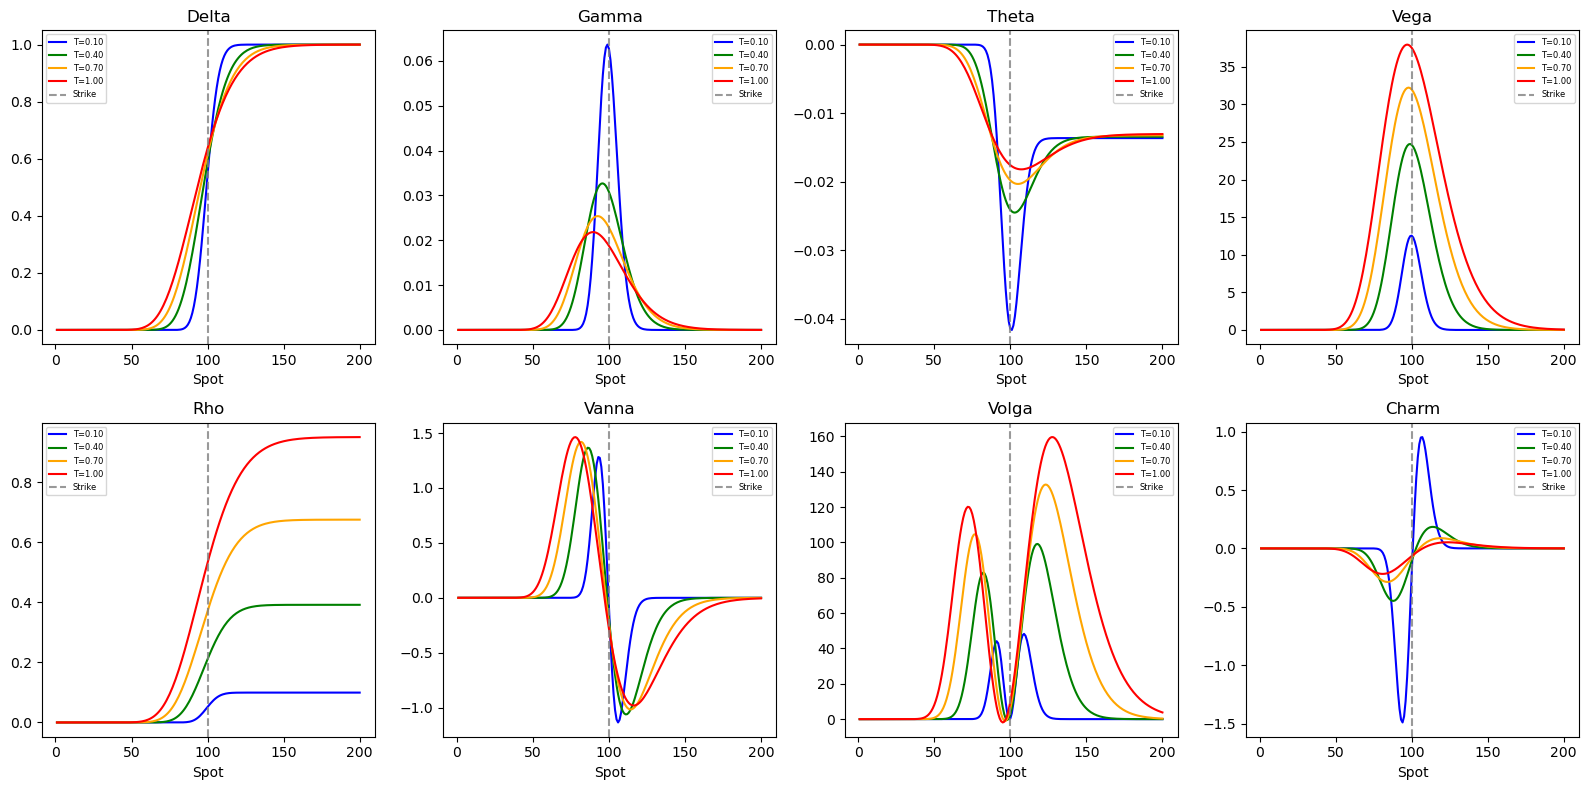

In [144]:
spot_range = np.linspace(start=S*0.01, stop=S*2, num=200)
time_range = np.linspace(start=T*0.1, stop=T, num=4)
metrics = ['Delta', 'Gamma', 'Theta', 'Vega', 'Rho', 'Vanna', 'Volga', 'Charm']

val = {j: {t: [] for t in time_range} for j in metrics}

for t in time_range:
    for i in spot_range:
        analytical = Analytical(i, K, r, t, sigma, q, option_type)
        greeks = analytical.greeks()
        for j in metrics:
            val[j][t].append(greeks[j])

plt.figure(figsize=(16, 8))
colors = ['blue', 'green', 'orange', 'red']

for idx, metric in enumerate(metrics):
    plt.subplot(2, 4, idx+1)
    for c, t in zip(colors, time_range):
        plt.plot(spot_range, val[metric][t], label=f'T={t:.2f}', color=c)
    plt.axvline(x=K, color='grey', linestyle='--', label='Strike', alpha=0.8)
    plt.title(metric)
    plt.xlabel('Spot')
    plt.legend(fontsize=6)

plt.tight_layout()
plt.show()

### vs Spot and Vol

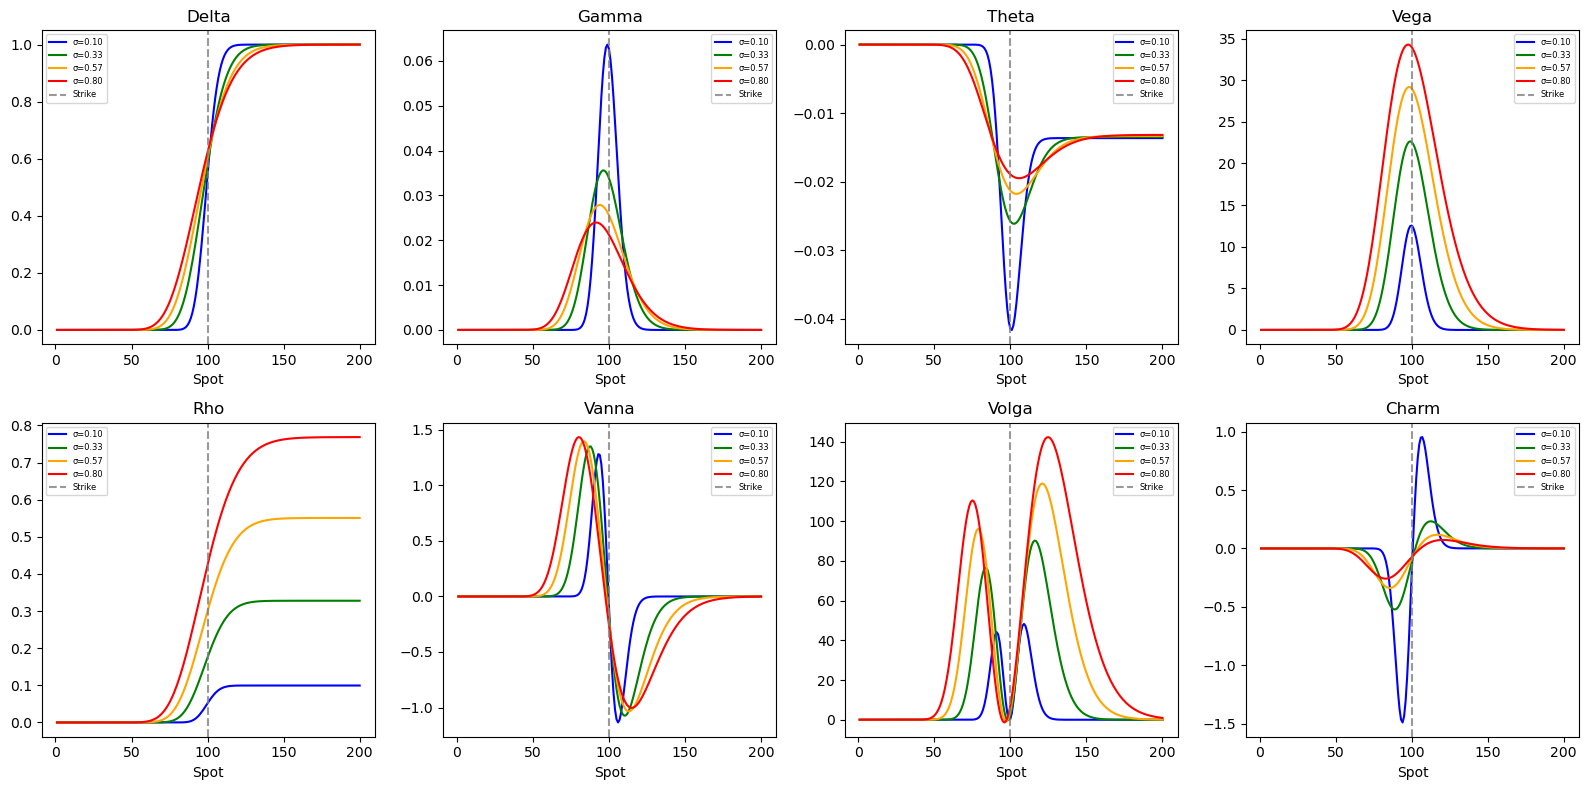

In [145]:
spot_range = np.linspace(start=S*0.01, stop=S*2, num=200)
vol_range = np.linspace(start=0.1, stop=0.8, num=4)
metrics = ['Delta', 'Gamma', 'Theta', 'Vega', 'Rho', 'Vanna', 'Volga', 'Charm']

val = {j: {t: [] for t in vol_range} for j in metrics}

for t in vol_range:
    for i in spot_range:
        analytical = Analytical(i, K, r, t, sigma, q, option_type)
        greeks = analytical.greeks()
        for j in metrics:
            val[j][t].append(greeks[j])

plt.figure(figsize=(16, 8))
colors = ['blue', 'green', 'orange', 'red']

for idx, metric in enumerate(metrics):
    plt.subplot(2, 4, idx+1)
    for c, t in zip(colors, vol_range):
        plt.plot(spot_range, val[metric][t], label=f'σ={t:.2f}', color=c)
    plt.axvline(x=K, color='grey', linestyle='--', label='Strike', alpha=0.8)
    plt.title(metric)
    plt.xlabel('Spot')
    plt.legend(fontsize=6)

plt.tight_layout()
plt.show()

## Vanilla Put Option 

In [146]:
S, K, r, T, sigma, q, option_type = 100, 100, 0.05, 1, 0.2, 0, 'put'

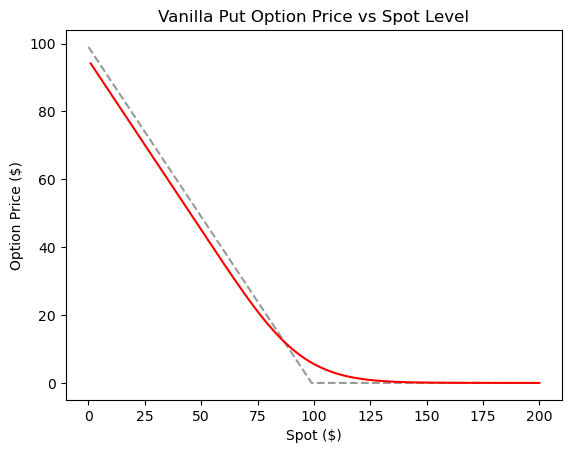

In [147]:
spot_range = np.linspace(start=S*0.01, stop=S*2, num=200)
val = []

for i in spot_range:
    analytical = Analytical(i, K, r, T, sigma, q, option_type)
    val.append(analytical.price())

intrinsic_val = [max(K-i, 0) for i in spot_range]

plt.plot(intrinsic_val, color='grey', alpha=0.8, linestyle='dashed')
plt.plot(spot_range, val, color='red')
plt.xlabel('Spot ($)')
plt.ylabel('Option Price ($)')
plt.title('Vanilla Put Option Price vs Spot Level')
plt.show()

## Greeks

### vs Spot

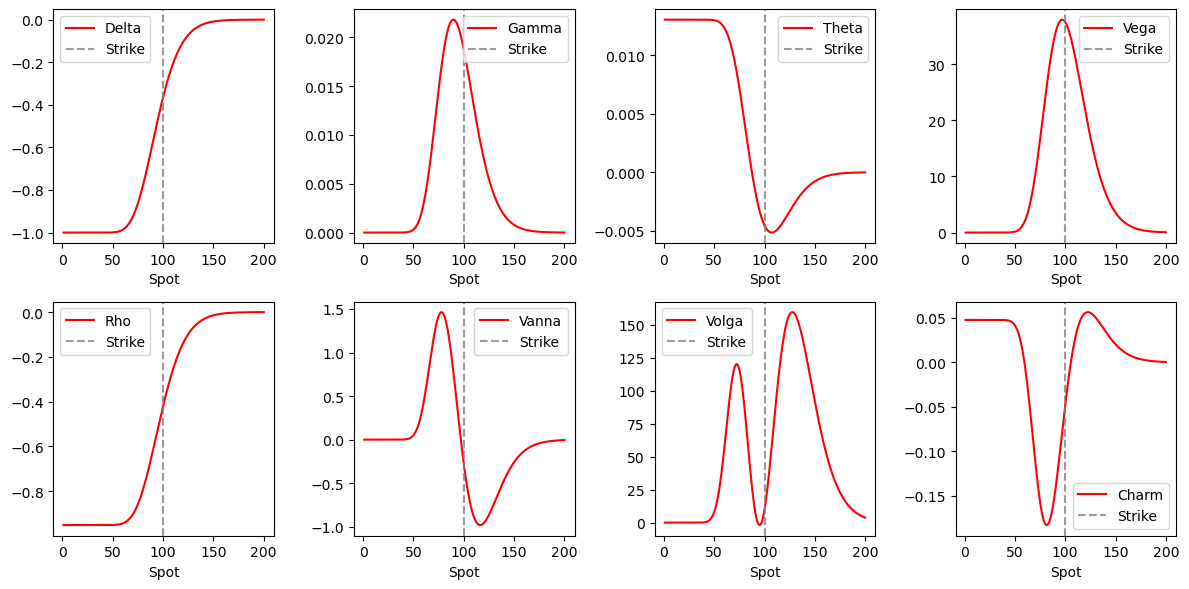

In [148]:
spot_range = np.linspace(start=S*0.01, stop=S*2, num=200)
metrics = ['Delta', 'Gamma', 'Theta', 'Vega', 'Rho', 'Vanna', 'Volga', 'Charm']

val = {j: [] for j in metrics}

for j in metrics:
    for i in spot_range:
        analytical = Analytical(i, K, r, T, sigma, q, option_type)
        val[j].append(analytical.greeks()[j])

plt.figure(figsize=(12,6))

for idx, i in enumerate(val):
    plt.subplot(2, 4, idx+1)
    plt.plot(spot_range, val[i], label=i, color='red')
    plt.axvline(x=K, color='grey', linestyle='--', label='Strike', alpha=0.8)
    plt.xlabel('Spot')
    plt.legend()

plt.tight_layout()
plt.show()

### vs Spot and Time

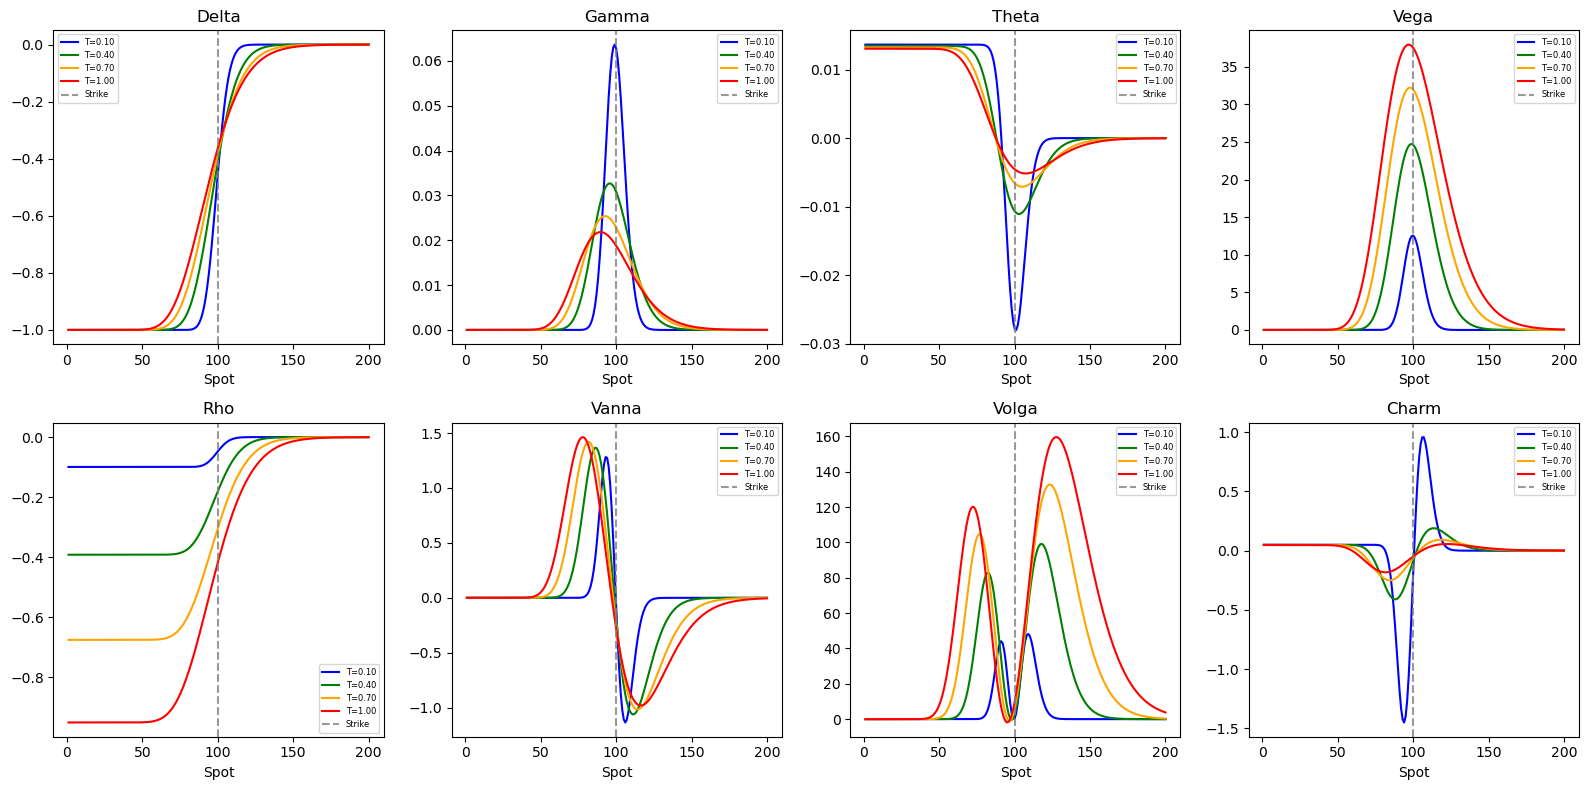

In [149]:
spot_range = np.linspace(start=S*0.01, stop=S*2, num=200)
time_range = np.linspace(start=T*0.1, stop=T, num=4)
metrics = ['Delta', 'Gamma', 'Theta', 'Vega', 'Rho', 'Vanna', 'Volga', 'Charm']

val = {j: {t: [] for t in time_range} for j in metrics}

for t in time_range:
    for i in spot_range:
        analytical = Analytical(i, K, r, t, sigma, q, option_type)
        greeks = analytical.greeks()
        for j in metrics:
            val[j][t].append(greeks[j])

plt.figure(figsize=(16, 8))
colors = ['blue', 'green', 'orange', 'red']

for idx, metric in enumerate(metrics):
    plt.subplot(2, 4, idx+1)
    for c, t in zip(colors, time_range):
        plt.plot(spot_range, val[metric][t], label=f'T={t:.2f}', color=c)
    plt.axvline(x=K, color='grey', linestyle='--', label='Strike', alpha=0.8)
    plt.title(metric)
    plt.xlabel('Spot')
    plt.legend(fontsize=6)

plt.tight_layout()
plt.show()

### vs Spot and Vol

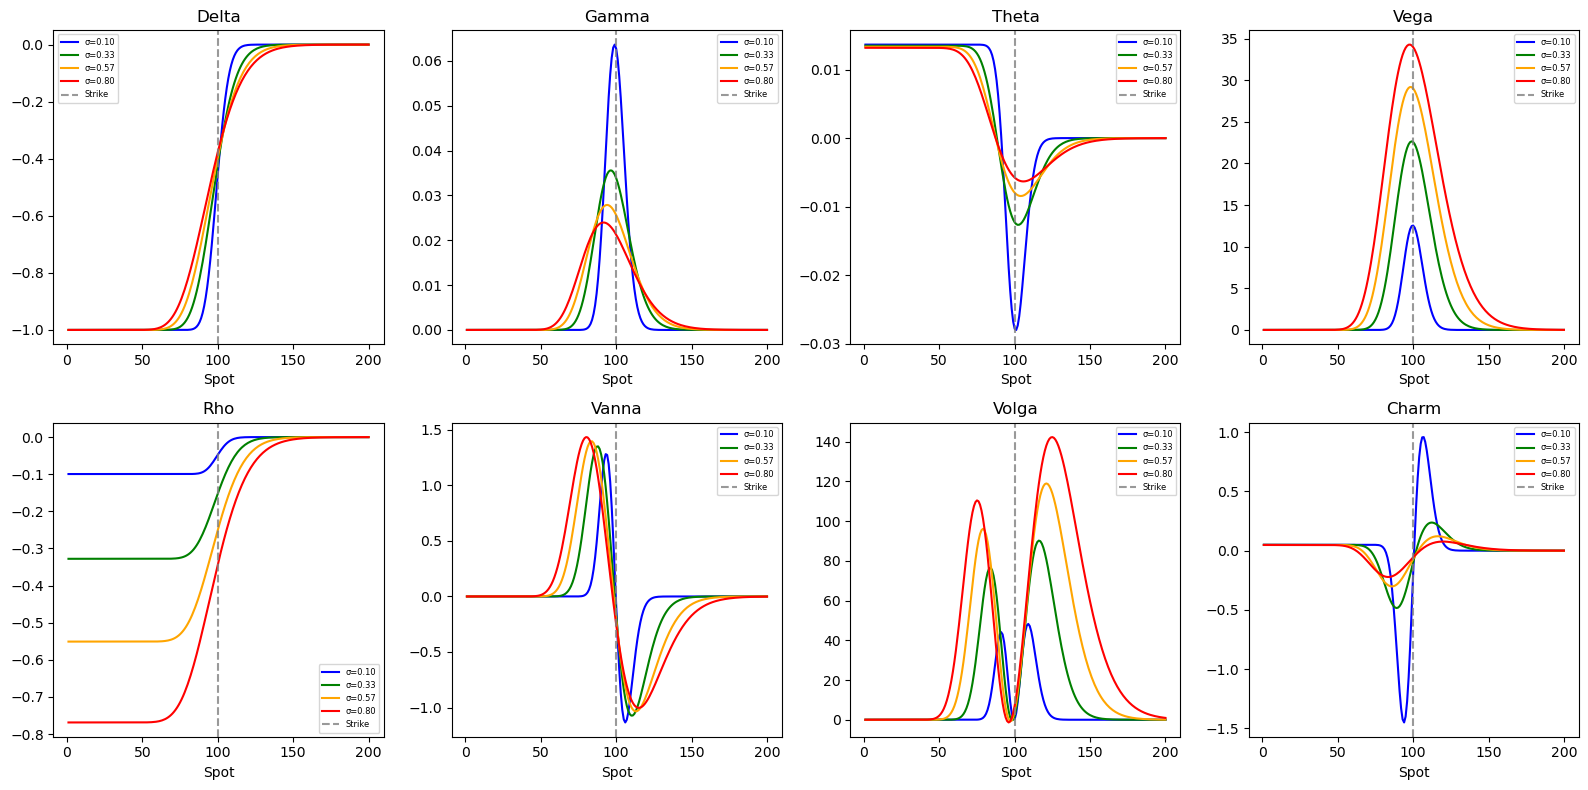

In [150]:
spot_range = np.linspace(start=S*0.01, stop=S*2, num=200)
vol_range = np.linspace(start=0.1, stop=0.8, num=4)
metrics = ['Delta', 'Gamma', 'Theta', 'Vega', 'Rho', 'Vanna', 'Volga', 'Charm']

val = {j: {t: [] for t in vol_range} for j in metrics}

for t in vol_range:
    for i in spot_range:
        analytical = Analytical(i, K, r, t, sigma, q, option_type)
        greeks = analytical.greeks()
        for j in metrics:
            val[j][t].append(greeks[j])

plt.figure(figsize=(16, 8))
colors = ['blue', 'green', 'orange', 'red']

for idx, metric in enumerate(metrics):
    plt.subplot(2, 4, idx+1)
    for c, t in zip(colors, vol_range):
        plt.plot(spot_range, val[metric][t], label=f'σ={t:.2f}', color=c)
    plt.axvline(x=K, color='grey', linestyle='--', label='Strike', alpha=0.8)
    plt.title(metric)
    plt.xlabel('Spot')
    plt.legend(fontsize=6)

plt.tight_layout()
plt.show()